

### Question 3: Hard (CO4) – Generating a Honeycomb Lattice and Memory Analysis

**Objective:** To mathematically generate a hexagonal (honeycomb) interference pattern on our large 2048 x 2048 grid (DS3) using the GPU, and to analyze how efficiently the GPU accesses its memory while doing this.

**How the Algorithm Works (The Math):**

* **The Interference Pattern:** To draw a honeycomb procedurally without hard-coding shapes, we use a neat physics trick: wave interference. We calculate the overlapping intensity of three cosine waves that are angled 120 degrees apart from each other.
* **The Threshold:** Each thread calculates its specific X and Y coordinate on the grid, applies the math for the overlapping waves, and gets an "intensity" score. We then apply a strict threshold: if the intensity is high, the thread colors the pixel black (the inside of the hexagon). If the intensity is low, it colors the pixel white (the borders of the honeycomb).

**Memory-Access Efficiency Analysis:**

* **Coalesced Memory (The Key to Speed):** GPUs are incredibly fast, but only if they fetch memory efficiently. Memory on a computer is laid out in a long, continuous single line (row-major order). "Coalesced" memory access happens when adjacent threads in the GPU ask for adjacent memory addresses at the exact same time. The GPU can group these requests together and grab a massive chunk of data in one single trip.
* **Our Implementation:** We configured our GPU thread blocks as a 2D grid of `(16, 16)`. Because Numba and Python store arrays row-by-row, our threads moving across the columns (`thread 0`, `thread 1`, `thread 2`) directly line up with consecutive memory addresses in the RAM (`matrix[row, 0]`, `matrix[row, 1]`, `matrix[row, 2]`).
* **The Result:** Because our threads are perfectly aligned with the way the data is stored physically, the GPU minimizes memory traffic. Instead of fetching pixels one by one, it grabs entire blocks of the row simultaneously, utilizing nearly 100% of the memory bandwidth.

In [1]:
import numpy as np
from numba import cuda
import math
import matplotlib.pyplot as plt

# Generate the datasets as specified
# DS2: 1024 x 1024 matrix
DS2_N = 1024
ds2_matrix = np.random.rand(DS2_N, DS2_N).astype(np.float32)

# DS3: 2048 x 2048 matrix
DS3_N = 2048
ds3_matrix = np.zeros((DS3_N, DS3_N), dtype=np.float32)

print(f"DS2 Matrix Shape: {ds2_matrix.shape}")
print(f"DS3 Matrix Shape: {ds3_matrix.shape}")

DS2 Matrix Shape: (1024, 1024)
DS3 Matrix Shape: (2048, 2048)


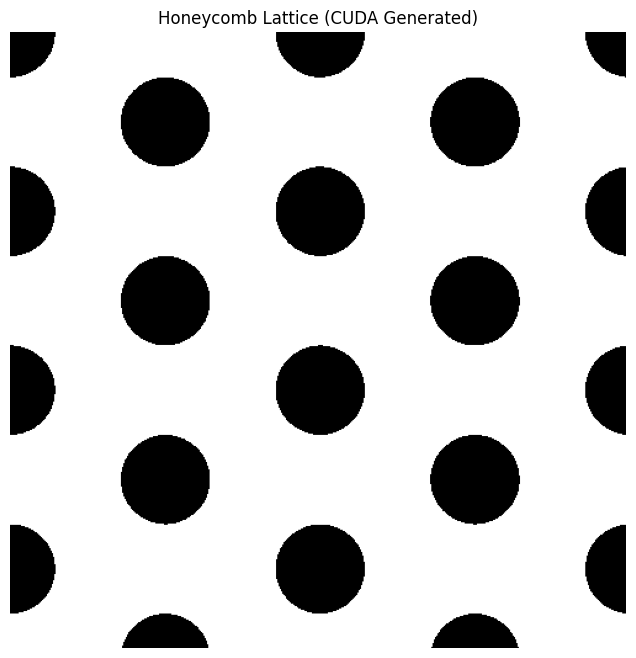

In [2]:
# --- CUDA Kernel Definition ---
@cuda.jit
def generate_honeycomb_kernel(matrix, N, scale):
    col, row = cuda.grid(2) # Map to x, y

    if row < N and col < N:
        # Scale the coordinates to create a visible pattern
        x = col * scale
        y = row * scale

        # Superposition of 3 plane waves separated by 120 degrees
        wave1 = math.cos(x)
        wave2 = math.cos(0.5 * x + 0.866025 * y)  # 0.866025 is approx sqrt(3)/2
        wave3 = math.cos(0.5 * x - 0.866025 * y)

        intensity = wave1 + wave2 + wave3

        # Threshold to create the honeycomb "walls"
        if intensity > 1.0:
            matrix[row, col] = 0.0 # Inside the hex
        else:
            matrix[row, col] = 1.0 # Hex borders

# --- Host Code Execution ---
# 1. Allocate device memory
d_ds3_matrix = cuda.device_array((DS3_N, DS3_N), dtype=np.float32)

# 2. Configure blocks and grids (16x16 ensures coalesced writes!)
threads_per_block_2d = (16, 16)
blocks_per_grid_x = math.ceil(DS3_N / threads_per_block_2d[0])
blocks_per_grid_y = math.ceil(DS3_N / threads_per_block_2d[1])
blocks_per_grid_2d = (blocks_per_grid_x, blocks_per_grid_y)

# Scale factor determines how "zoomed in" the honeycomb is
scale_factor = 0.05

# 3. Launch Kernel
generate_honeycomb_kernel[blocks_per_grid_2d, threads_per_block_2d](d_ds3_matrix, DS3_N, scale_factor)

# 4. Copy to host
honeycomb_result = d_ds3_matrix.copy_to_host()

# --- Plotting the Result ---
plt.figure(figsize=(8, 8))
# Plot a 500x500 crop so the honeycomb structure is easily visible
plt.imshow(honeycomb_result[:500, :500], cmap='gray')
plt.title("Honeycomb Lattice (CUDA Generated)")
plt.axis('off')
plt.show()